In [ ]:
import os
from google.colab import drive
import numpy as np
import pandas as pd
import cv2
from scipy.stats import skew, entropy
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import joblib

## MOUNT DRIVE & DATA STRUCTURING

In [ ]:
drive.mount('/content/drive')
dataset_dir = '/content/drive/MyDrive/UAS Data Science/dataset_tumor_otak'
print(f"\nMencari data di: {dataset_dir}")

all_data = []
# Looping untuk mengambil path dan target kelas dari folder
for root, dirs, files in os.walk(dataset_dir):
    for file in files:
        if file.endswith(('.jpg', '.png', '.jpeg')):
            path = os.path.join(root, file)
            label = os.path.basename(root)
            all_data.append({'Image_Path': path, 'Target_Label': label})

df = pd.DataFrame(all_data)
print(f"Total gambar yang ditemukan: {len(df)} gambar.")
display(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Mencari data di: /content/drive/MyDrive/UAS Data Science/dataset_tumor_otak
Total gambar yang ditemukan: 7200 gambar.


,Image_Path,Target_Label
0,/content/drive/MyDrive/UAS Data Science/datase...,pituitary
1,/content/drive/MyDrive/UAS Data Science/datase...,pituitary
2,/content/drive/MyDrive/UAS Data Science/datase...,pituitary
3,/content/drive/MyDrive/UAS Data Science/datase...,pituitary
4,/content/drive/MyDrive/UAS Data Science/datase...,pituitary


## Data Preprocessing (Ekstraksi Fitur Statistik)

In [ ]:
print(f"Mengekstrak fitur statistik dari {len(df)} citra MRI...")
extracted_features = []

for index, row in tqdm(df.iterrows(), total=df.shape[0], desc="Proses Ekstraksi"):
    # Baca gambar dalam format Grayscale (Hitam Putih)
    img = cv2.imread(row['Image_Path'], cv2.IMREAD_GRAYSCALE)

    if img is not None:
        # Menghitung fitur statistik dari piksel gambar
        mean_val = np.mean(img)
        std_val = np.std(img)
        skewness_val = skew(img.flatten())

        # Menghitung Entropy
        hist, _ = np.histogram(img.flatten(), bins=256, range=(0,255))
        entropy_val = entropy(hist + 1e-7)

        extracted_features.append({
            'Target_Label': row['Target_Label'],
            'Mean_Intensity': mean_val,
            'Std_Deviation': std_val,
            'Skewness': skewness_val,
            'Entropy': entropy_val
        })

# Simpan hasil ekstraksi ke dalam DataFrame baru
df_features = pd.DataFrame(extracted_features)
print("Ekstraksi Selesai! Data siap dianalisis.")
display(df_features.head())

Mengekstrak fitur statistik dari 7200 citra MRI...


Proses Ekstraksi: 100%|██████████| 7200/7200 [02:30<00:00, 47.81it/s]

Ekstraksi Selesai! Data siap dianalisis.


,Target_Label,Mean_Intensity,Std_Deviation,Skewness,Entropy
0,pituitary,40.995617,38.880632,1.050988,4.269688
1,pituitary,53.817429,45.676158,0.679193,4.507432
2,pituitary,39.800488,44.045064,0.785165,3.906781
3,pituitary,38.694794,38.392227,0.900112,4.043531
4,pituitary,55.282166,40.974956,1.043873,4.817195


## EXPLORATORY DATA ANALYSIS (EDA)

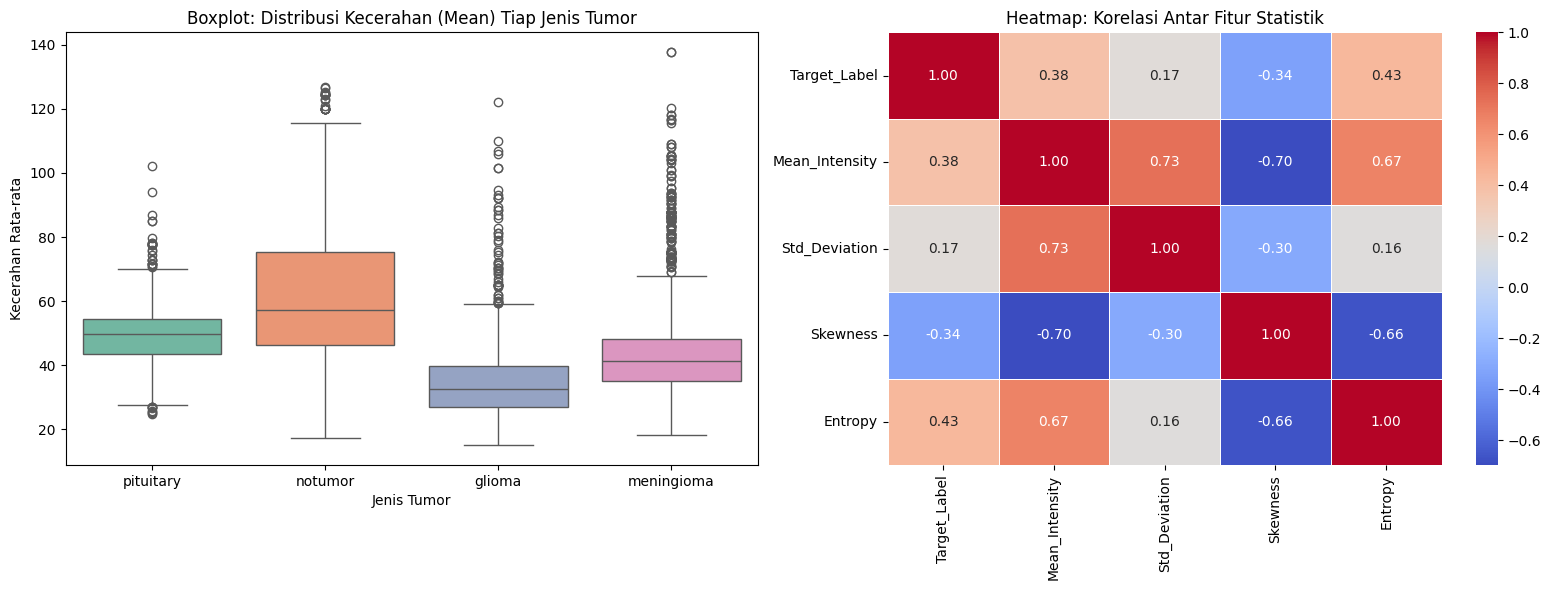

In [ ]:
plt.figure(figsize=(16, 6))

# Sebaran data dan outlier tiap kelas tumor
plt.subplot(1, 2, 1)
sns.boxplot(data=df_features, x='Target_Label', y='Mean_Intensity', hue='Target_Label', palette='Set2', legend=False)
plt.title('Boxplot: Distribusi Kecerahan (Mean) Tiap Jenis Tumor')
plt.xlabel('Jenis Tumor')
plt.ylabel('Kecerahan Rata-rata')

# Hubungan antar fitur statistik
plt.subplot(1, 2, 2)
df_corr = df_features.copy()
df_corr['Target_Label'] = df_corr['Target_Label'].astype('category').cat.codes
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap: Korelasi Antar Fitur Statistik')

plt.tight_layout()
plt.show()

## DATA SPLIT & STANDARDIZATION


In [ ]:
X = df_features.drop('Target_Label', axis=1)
y = df_features['Target_Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

# Standarisasi data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Data Latih (Train): {X_train.shape[0]} baris")
print(f"Data Uji (Test)  : {X_test.shape[0]} baris")

Data Latih (Train): 5760 baris
Data Uji (Test)  : 1440 baris


## TRAINING MACHINE LEARNING MODELS

In [ ]:
print("Melatih Model 1: Random Forest Classifier...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
rf_pred_proba = rf_model.predict_proba(X_test_scaled)

print("Melatih Model 2: Support Vector Machine (SVM)...")
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
svm_pred_proba = svm_model.predict_proba(X_test_scaled)

print("Kedua model berhasil dilatih!")

Melatih Model 1: Random Forest Classifier...
Melatih Model 2: Support Vector Machine (SVM)...
Kedua model berhasil dilatih!


## EVALUATION & FEATURE IMPORTANCE


HASIL EVALUASI: RANDOM FOREST
              precision    recall  f1-score   support

      glioma       0.79      0.78      0.78       360
  meningioma       0.79      0.77      0.78       360
     notumor       0.95      0.97      0.96       360
   pituitary       0.84      0.86      0.85       360

    accuracy                           0.85      1440
   macro avg       0.84      0.85      0.84      1440
weighted avg       0.84      0.85      0.84      1440

Skor AUC-ROC: 0.9609

HASIL EVALUASI: SUPPORT VECTOR MACHINE (SVM)
              precision    recall  f1-score   support

      glioma       0.68      0.68      0.68       360
  meningioma       0.58      0.59      0.58       360
     notumor       0.79      0.84      0.81       360
   pituitary       0.76      0.71      0.73       360

    accuracy                           0.70      1440
   macro avg       0.70      0.70      0.70      1440
weighted avg       0.70      0.70      0.70      1440

Skor AUC-ROC: 0.8879

INTERPRETA

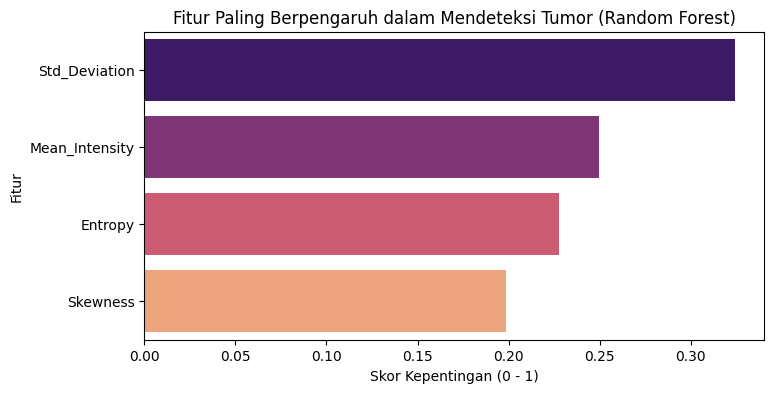

In [ ]:
def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    print(f"\n{'='*50}")
    print(f"HASIL EVALUASI: {model_name.upper()}")
    print("="*50)

    # Metrik utama
    print(classification_report(y_true, y_pred))

    # AUC-ROC Score
    auc = roc_auc_score(y_true, y_pred_proba, multi_class='ovr')
    print(f"Skor AUC-ROC: {auc:.4f}")

# Menampilkan Evaluasi
evaluate_model(y_test, rf_pred, rf_pred_proba, "Random Forest")
evaluate_model(y_test, svm_pred, svm_pred_proba, "Support Vector Machine (SVM)")

# INTERPRETASI FEATURE IMPORTANCE
print("\n" + "="*50)
print("INTERPRETASI: FITUR YANG PALING BERPENGARUH")
print("="*50)

# Mengambil nilai bobot dari Random Forest
importances = rf_model.feature_importances_
feature_names = X.columns
feature_imp_df = pd.DataFrame({'Fitur': feature_names, 'Tingkat Kepentingan': importances})
feature_imp_df = feature_imp_df.sort_values(by='Tingkat Kepentingan', ascending=False)

# Visualisasi Feature Importance
plt.figure(figsize=(8, 4))
sns.barplot(x='Tingkat Kepentingan', y='Fitur', data=feature_imp_df, hue='Fitur', palette='magma', legend=False)
plt.title('Fitur Paling Berpengaruh dalam Mendeteksi Tumor (Random Forest)')
plt.xlabel('Skor Kepentingan (0 - 1)')
plt.show()

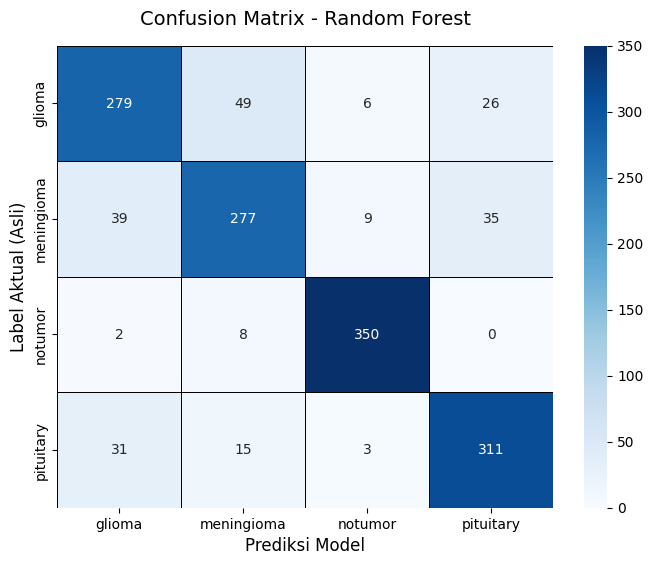

In [ ]:
# Hitung Confusion Matrix dari hasil testing
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(8, 6))
classes = rf_model.classes_

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, linecolor='black')

plt.title('Confusion Matrix - Random Forest', fontsize=14, pad=15)
plt.xlabel('Prediksi Model', fontsize=12)
plt.ylabel('Label Aktual (Asli)', fontsize=12)
plt.show()

In [ ]:
# Simpan model Random Forest terbaik
joblib.dump(rf_model, 'model_tumor_rf.pkl')

# Simpan scaler agar standarisasi data di Streamlit konsisten
joblib.dump(scaler, 'scaler_tumor.pkl')

['scaler_tumor.pkl']